In [1]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent 
sys.path.append(str(ROOT.parent)) 

In [2]:
#!{sys.executable} -m pip install ipywidgets
from neurodiffeq.neurodiffeq import diff
from neurodiffeq.neurodiffeq.solvers import Solver1D, Solver2D
from neurodiffeq.neurodiffeq.conditions import IVP, DirichletBVP2D
from neurodiffeq.neurodiffeq.networks import FCNN, SinActv
from neurodiffeq.neurodiffeq.monitors import Monitor1D
import numpy as np
import torch
#%matplotlib widget
#import matplotlib.pyplot as plt

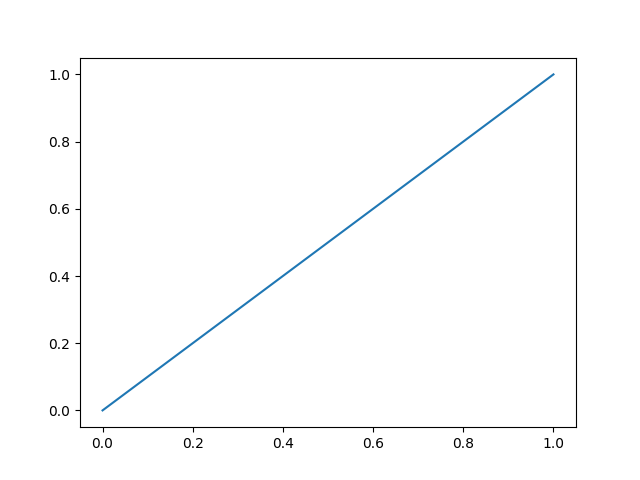

In [3]:
%matplotlib widget
import matplotlib.pyplot as plt

plt.plot(np.linspace(0., 1., 100), np.linspace(0., 1., 100))
plt.show()

In [7]:
class PositiveConstraintSolver(Solver1D):
    def additional_loss(self, residuals, funcs, batch):
        penalties = [torch.relu(-u).mean() for u in funcs]
        total = torch.stack(penalties).sum()
        #print(f"CALL ADDITIONAL_LOSS: {total}")
        return 0.5
        #return torch.stack(penalties).sum()

In [4]:
class PopulationConstraintSolver(Solver1D):
    def additional_loss(self, residuals, funcs, batch):
        u, v = funcs
        total = u + v
        target = 2.5  # arbitrary constant (you can tune this)
        return ((total - target) ** 2).mean()

In [ ]:
def ode_system(u, v, t): 
    return [diff(u,t)-(u-u*v), diff(v,t)-(u*v-v)]

conditions = [IVP(t_0=0.0, u_0=1.5), IVP(t_0=0.0, u_0=1.0)]
nets = [FCNN(actv=SinActv), FCNN(actv=SinActv)]

#solver = Solver1D(ode_system, conditions, t_min=0.1, t_max=12.0, nets=nets, track_loss_components=True)
#solver = PositiveConstraintSolver(ode_system, conditions, t_min=0.1, t_max=12.0, nets=nets, track_loss_components=True)
solver = PopulationConstraintSolver(ode_system, conditions, t_min=0.1, t_max=12.0, nets=nets, track_loss_components=True)
monitor = Monitor1D(t_min=0.0, t_max=12.0, check_every=100)
solver.fit(max_epochs=3000, callbacks=[monitor.to_callback()])
solution = solver.get_solution()

In [6]:
t = np.linspace(0., 12.0, 1000)
u, v = solution(t, to_numpy=True)  # t can be np.ndarray or torch.Tensor

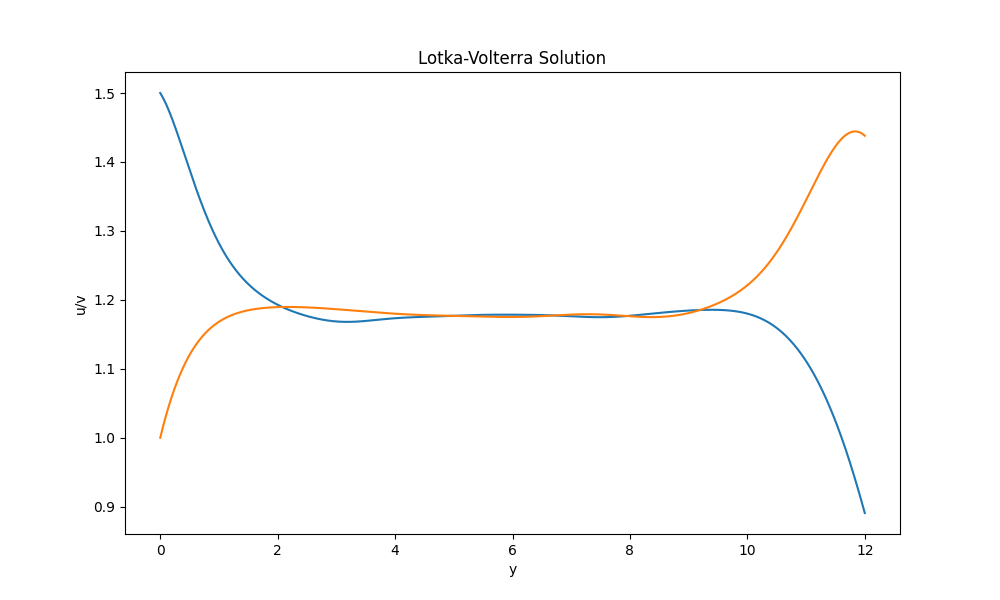

In [7]:

fig= plt.figure(figsize=(10,6))
plt.title("Lotka-Volterra Solution")
plt.xlabel("y")
plt.ylabel("u/v")
plt.plot(t,u)
plt.plot(t,v)
plt.show()